In [1]:
import tensorflow as tf
import numpy as np

In [2]:
fashion_mnist = tf.keras.datasets.fashion_mnist
(x_train_total, y_train_total), (x_test_total, y_test_total) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
from sklearn.model_selection import train_test_split

In [5]:
x_train, _, y_train, _ = train_test_split(x_train_total,
                                          y_train_total,
                                          test_size=0.9,
                                          random_state=1502)
x_test, _, y_test, _ = train_test_split(x_test_total,
                                        y_test_total,
                                        test_size=0.9,
                                        random_state=1502)

In [6]:
print(f"Training dataset shape: {x_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Testing dataset shape: {x_test.shape}")
print(f"Testing labels shape: {y_test.shape}")

Training dataset shape: (6000, 28, 28)
Training labels shape: (6000,)
Testing dataset shape: (1000, 28, 28)
Testing labels shape: (1000,)


In [7]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

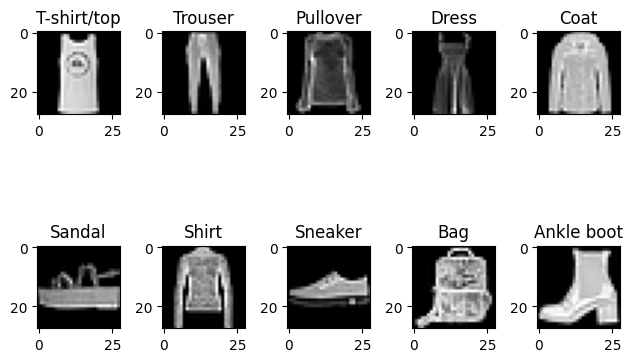

In [9]:
import matplotlib.pyplot as plt
for i in range(10):
    idx = np.random.choice(np.where(y_train == i)[0])
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[idx], cmap='gray')
    plt.title(class_names[i])
plt.tight_layout()
plt.show()

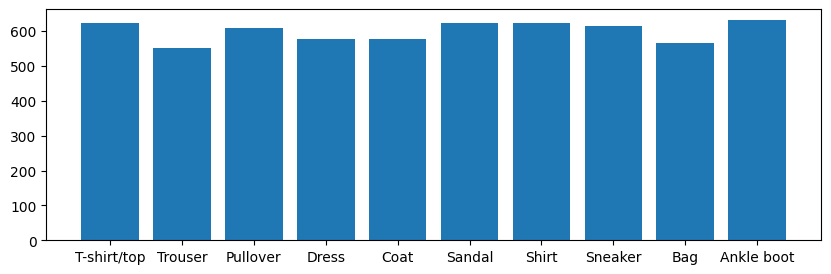

In [10]:
plt.figure(figsize=(10,3))
plt.hist(y_train, bins=np.arange(11)-0.5, rwidth=0.8)
plt.xticks(np.arange(10), class_names)
plt.show()

In [11]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [12]:
x_train = x_train.reshape((-1, 28, 28, 1))
x_test = x_test.reshape((-1, 28, 28, 1))

In [13]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
   rotation_range=10,
   zoom_range=0.1,
   shear_range=0.1,
   width_shift_range=0.1,
   height_shift_range=0.1,
   horizontal_flip=True
)

In [14]:
datagen.fit(x_train)

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [16]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(2, 2),
    Dropout(0.2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2, 2),
    Dropout(0.2),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
       ])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [18]:
history = model.fit(datagen.flow(x_train,
                                 y_train,
                                 batch_size=32),
                    epochs=5,
                    validation_data=(x_test,
                                     y_test))

Epoch 1/5


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


188/188 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step - accuracy: 0.3719 - loss: 1.6991 - val_accuracy: 0.6830 - val_loss: 0.8170
Epoch 2/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.6310 - loss: 0.9648 - val_accuracy: 0.7060 - val_loss: 0.7270
Epoch 3/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.6855 - loss: 0.8182 - val_accuracy: 0.7360 - val_loss: 0.6414
Epoch 4/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 12s 62ms/step - accuracy: 0.7037 - loss: 0.8078 - val_accuracy: 0.7440 - val_loss: 0.6162
Epoch 5/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - accuracy: 0.7223 - loss: 0.7291 - val_accuracy: 0.7300 - val_loss: 0.6339


In [19]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy',
                                              patience=5)

In [20]:
def lr_schedule(epoch, lr):
    if epoch > 10:
        return lr * 0.1
    return lr

In [21]:
scheduler = tf.keras.callbacks.LearningRateScheduler(lr_schedule)


In [22]:
history = model.fit(datagen.flow(x_train,
                                 y_train,
                                 batch_size=32),
                    epochs=20,
                    validation_data=(x_test,
                                     y_test),
                    callbacks=[early_stop, scheduler])

Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.7279 - loss: 0.7016 - val_accuracy: 0.7630 - val_loss: 0.5557 - learning_rate: 0.0010
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.7375 - loss: 0.6778 - val_accuracy: 0.7830 - val_loss: 0.5484 - learning_rate: 0.0010
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 18s 85ms/step - accuracy: 0.7391 - loss: 0.6683 - val_accuracy: 0.7640 - val_loss: 0.5603 - learning_rate: 0.0010
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 15s 59ms/step - accuracy: 0.7527 - loss: 0.6403 - val_accuracy: 0.7700 - val_loss: 0.5559 - learning_rate: 0.0010
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.7474 - loss: 0.6475 - val_accuracy: 0.7960 - val_loss: 0.5099 - learning_rate: 0.0010
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 12s 64ms/step - accuracy: 0.7657 - loss: 0.6154 - val_accuracy: 0.7760 - val_loss: 0.5413 - learning_rate: 0.0010
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - accuracy: 0.7655 - lo

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

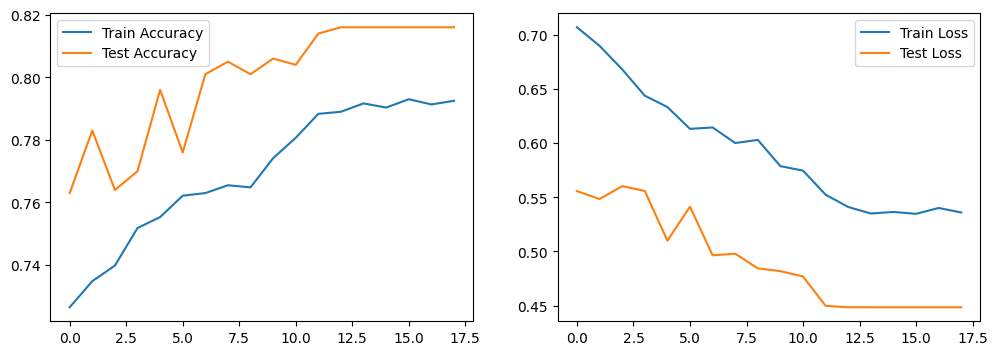

In [24]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.legend()
plt.show()

In [25]:
y_pred = model.predict(x_test)
cm = confusion_matrix(y_test, np.argmax(y_pred, axis=1))

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


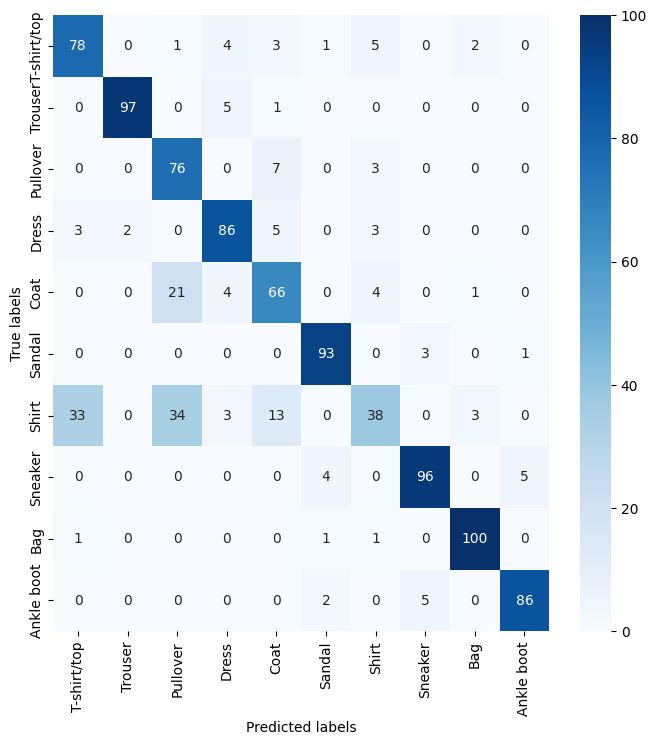

In [26]:
plt.figure(figsize=(8,8))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.show()

In [27]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    last_conv_layer = model.get_layer(last_conv_layer_name)
    last_conv_layer_model = tf.keras.Model(model.inputs, last_conv_layer.output)
    last_conv_layer_idx = [layer.name for layer in model.layers].index(last_conv_layer_name)
    classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
    x = classifier_input
    for layer in model.layers[last_conv_layer_idx+1:]:
        x = layer(x)
    classifier_model = tf.keras.Model(classifier_input, x)
    with tf.GradientTape() as tape:
        last_conv_layer_output = last_conv_layer_model(img_array)
        tape.watch(last_conv_layer_output)
        preds = classifier_model(last_conv_layer_output)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]
    grads = tape.gradient(class_channel, last_conv_layer_output)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output * pooled_grads[tf.newaxis, tf.newaxis, tf.newaxis, :]

    heatmap = tf.reduce_mean(last_conv_layer_output, axis=-1)[0]

    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)

    return heatmap

In [28]:
for layer in model.layers:
    print(layer.name)

conv2d
max_pooling2d
dropout
conv2d_1
max_pooling2d_1
dropout_1
flatten
dense
dropout_2
dense_1


In [29]:
img_array = x_test[np.random.choice(x_test.shape[0])]
img_array = img_array[np.newaxis, :]

In [30]:
preds = model.predict(img_array)
top_pred_index = np.argmax(preds[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [31]:
heatmap = make_gradcam_heatmap(img_array, model, 'conv2d', top_pred_index)

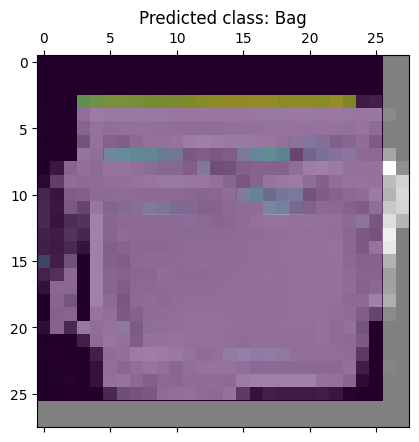

In [32]:
plt.matshow(heatmap)
plt.imshow(img_array.reshape(28, 28), cmap='gray', alpha=0.5)
plt.title(f"Predicted class: {class_names[top_pred_index]}")

plt.show()

In [33]:
model.save("cnn_model.keras")

In [34]:
loaded_model = tf.keras.models.load_model("cnn_model.keras")

In [35]:
random_idx = np.random.choice(len(x_test))
test_img = x_test[random_idx]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step


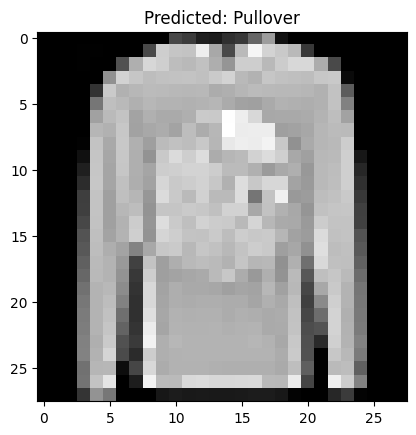

In [36]:
plt.imshow(test_img.reshape(28, 28), cmap='gray')
predictions = loaded_model.predict(test_img.reshape(1, 28, 28, 1))
predicted_class = np.argmax(predictions)
plt.title(f"Predicted: {class_names[predicted_class]}")
plt.show()